# Create Conjunction List
Find all conjunctions of in situ Swarm satellites with GNSS scintillation measurments for a particular reciever over a given period of time.

*Right now this code will only work RELIABLY for incriments of one day (see [GNSS section](#GNSS-Satellites)).*

In [1]:
import numpy as np
import datetime as dt
import pymap3d as pm
import pandas as pd
import csv
from satgroundconj.conjunction import SatConj
#import gnssutils
#from gnssutils.map_prn import prn2norad
from gnssutils import map_prn, calc_ipp
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

Define the CHAIN reciever and look up the coordinates in the site file.

In [2]:
receiver_name = 'res'

with open('CHAINsites.txt', 'r') as cf:
    chain_data = csv.reader(cf)
    for row in chain_data:
        if row[1] == receiver_name:
            receiver_site = [float(row[2]), float(row[3]), 0.]

print(receiver_site)

[74.746627, 264.997469, 0.0]


Define some basic parameters of the conjunction search.

In [3]:
output_file = f'insitu_gnss_conj_{receiver_name}.txt'

starttime = dt.datetime(2024,5,10)
endtime = dt.datetime(2024,5,11)

elev_cutoff = 30.    # Minimum elevation angle to consider for GNSS (deg)
tstep = 10.          # Time step for calculating satellite position (s)
conj_threshold = 10. # Angular separation threshold to count conjunctions (deg)


## In Situ Satellites
Define satellites, their NORAD numbers, and the period when they were orbiting.

In [4]:
# Swarm A, B, C; LLITED A, B
insitu_sats = [{'name': 'Swarm A', 'NORAD': 39452, 'start': dt.datetime(2013,12,2), 'end': dt.datetime.now()},
               {'name': 'Swarm B', 'NORAD': 39451, 'start': dt.datetime(2013,12,2), 'end': dt.datetime.now()},
               {'name': 'Swarm C', 'NORAD': 39453, 'start': dt.datetime(2013,12,2), 'end': dt.datetime.now()}]

Find passes for in situ satellites.

In [5]:
# Generate lists of all passes for in situ satellites
print('Finding passes for In Situ...')
passes_insitu = list()
for sat in insitu_sats:
    print(sat['name'], 'NORAD ID:', sat['NORAD'])
    # Initialize conjunction object
    insitu = SatConj(receiver_site, sat['NORAD'], tolerance=90.-elev_cutoff, deltime=tstep, tledb='/Users/e30737/Desktop/Data/TLE/tle_full.db')
    # Find correct time bounds
    if starttime > sat['start']:
        st = starttime.replace(tzinfo=None)
    else:
        st = sat['start'].replace(tzinfo=None)
    if endtime < sat['end']:
        et = endtime.replace(tzinfo=None)
    else:
        et = sat['end'].replace(tzinfo=None)
    # Calculate conjunctions with ground site
    passes = insitu.conjunctions(st, et)
    # Add satellite name and ID to each pass item
    for p in passes:
        p['name'] = sat['name']
        p['NORAD'] = sat['NORAD']
    passes_insitu.extend(passes)

print(len(passes_insitu))

Finding passes for In Situ...
Swarm A NORAD ID: 39452
Swarm B NORAD ID: 39451
Swarm C NORAD ID: 39453
14


## GNSS Satellites

**Important:** Currently, the `prn2norad` fuction only returns the NORAD satellite number for the start of the interval.  If the PRN is reassigned during the interval to a different satellite, the conjunction calculation will not work correctly (it will be calculating conjunctions with the wrong physical satellite).  To make this work over arbitrarily large ranges instead of just one day, we need to reconfigure it to account for PRNs being assigned to different satellite.  The function `retrieve_prn_mapping_info` should return the appropriate tables.  I think the best way to do this would be to break the time periods up into windows when different PRNs were active.

In [6]:
# Generate lists of all passes for GNSS satellites
print('Finding passes for GNSS...')
passes_gnss = list()
for gnum in range(1,32):
    prn = f'G{gnum:02d}'

    sat_id = map_prn.prn2norad(prn, starttime)   # This only finds the NORAD number for a set date - will be a problem when searching across large time periods because these change
    print(prn, 'NORAD ID:', sat_id)
    if not sat_id:
        continue

    # Initalize conjunction object
    gnss = SatConj(receiver_site, sat_id, tolerance=90.-elev_cutoff, deltime=tstep, tledb='/Users/e30737/Desktop/Data/TLE/tle_full.db')
    # Find the correct time bounds
    if starttime > sat['start']:
        st = starttime.replace(tzinfo=None)
    else:
        st = sat['start'].replace(tzinfo=None)
    if endtime < sat['end']:
        et = endtime.replace(tzinfo=None)
    else:
        et = sat['end'].replace(tzinfo=None)
    # Calculate conjunctions with ground site
    passes = gnss.conjunctions(st, et)
    # Add satellite name and ID to each pass item
    for p in passes:
        p['PRN'] = prn
        p['NORAD'] = sat_id
    passes_gnss.extend(passes)

print(len(passes_gnss))

Finding passes for GNSS...
G01 NORAD ID: 34661
G02 NORAD ID: 28474
G03 NORAD ID: 40294
G04 NORAD ID: 43873
G05 NORAD ID: 35752
G06 NORAD ID: 39741
G07 NORAD ID: 32711
G08 NORAD ID: 40730
G09 NORAD ID: 40105
G10 NORAD ID: 41019
G11 NORAD ID: 48859
G12 NORAD ID: 29601
G13 NORAD ID: 24876
G14 NORAD ID: 46826
G15 NORAD ID: 32260
G16 NORAD ID: 27663
G17 NORAD ID: 28874
G18 NORAD ID: 44506
G19 NORAD ID: 28190
G20 NORAD ID: 26360
G21 NORAD ID: 27704
G22 NORAD ID: 26407
G23 NORAD ID: 45854
G24 NORAD ID: 38833
G25 NORAD ID: 36585
G26 NORAD ID: 40534
G27 NORAD ID: 39166
G28 NORAD ID: 55268
G29 NORAD ID: 32384
G30 NORAD ID: 39533
G31 NORAD ID: 29486
58


## Calculate Conjunctions

Haversine equation for calculating the angular distance between two sky points.

In [7]:
def haversine(phi1, phi2, lam1, lam2):
    """
    https://en.wikipedia.org/wiki/Haversine_formula
    Following convention in wikipedia article, phi are latitude/elevation coordinates and lambda are longitude/azimuth coordinates.
    """
    
    p1 = np.deg2rad(phi1)
    p2 = np.deg2rad(phi2)
    l1 = np.deg2rad(lam1)
    l2 = np.deg2rad(lam2)
    
    hav = np.sin((p2-p1)/2.)**2 + np.cos(p1)*np.cos(p2)*np.sin((l2-l1)/2.)**2
    dist = 2*np.arcsin(np.sqrt(hav))
    
    return np.rad2deg(dist)
 

Find conjunctions by iterating through every pair of in situ passes and gnss passes and selecting times when the following conditions are met:
1. The two passes occur at the same time (at least one time stamp the same between the two passes).
2. The closest the two satellites get during the pass is less than the threshold separation.

**Note** We might be able to do something clever where the initial selection of passes is at a relatively coarse resolution (1 min) but recalculate the position of the satellites at finer resolutions to better compute how closely they intersect.  That would probably involve calling the TLE propigation module somewhere in here?

In [8]:
print('Calculating conjunctions...')

conjlist = list()

# Cycle through all identified gnss and in situ passes
for pi in passes_insitu:
    for pg in passes_gnss:

        # Find common times between the two passes (the majority of pairs will have none)
        common_times = np.argwhere(pi['time'][:,None]==pg['time'][None,:])
        # If no common times, continue
        if len(common_times) == 0:
            continue

        # Pull out time and positions for both in situ and gnss passes at the common times
        ctimes = pi['time'][common_times[:,0]]
        xi, yi, zi = pi['position'][common_times[:,0],:].T
        xg, yg, zg = pg['position'][common_times[:,1],:].T

        # Calculate angular position
        ai, ei, ri = pm.ecef2aer(xi, yi, zi, *receiver_site)
        ag, eg, rg = pm.ecef2aer(xg, yg, zg, *receiver_site)

        # Calculate angular distance
        dist = haversine(ei, eg, ai, ag)
        min_idx = np.argmin(dist)  # index of closest intersection
        mindist = dist[min_idx]
        mintime = ctimes[min_idx]

        # If minimum distance less than threshold, add pair of passes to conjunction list
        if mindist < 10.:
            pass_info = pd.DataFrame({'time':ctimes, 'xi':xi, 'yi':yi, 'zi':zi, 'xg':xg, 'yg':yg, 'zg':zg, 'dist':dist})
            conj = {'Name':pi['name'], 'InSituNORAD':pi['NORAD'], 'PRN':pg['PRN'], 'GNSSNORAD':pg['NORAD'], 'mintime':mintime, 'mindist':mindist, 'pass_info':pass_info}
            conjlist.append(conj)

total_conjunctions = len(conjlist)
conjdf = pd.DataFrame(conjlist)

print('Total Conjunctions:', total_conjunctions)


Calculating conjunctions...
Total Conjunctions: 11


In [9]:
conjdf

,Name,InSituNORAD,PRN,GNSSNORAD,mintime,mindist,pass_info
0,Swarm A,39452,G15,32260,2024-05-10 00:26:10,2.420439,time xi ...
1,Swarm A,39452,G17,28874,2024-05-10 14:23:20,1.472544,time xi ...
2,Swarm A,39452,G22,26407,2024-05-10 14:24:00,2.824256,time xi ...
3,Swarm A,39452,G13,24876,2024-05-10 23:56:50,1.471758,time xi ...
4,Swarm B,39451,G12,29601,2024-05-10 04:49:10,8.441457,time xi ...
5,Swarm B,39451,G03,40294,2024-05-10 06:23:20,5.812606,time xi ...
6,Swarm B,39451,G12,29601,2024-05-10 17:35:30,1.162922,time xi ...
7,Swarm C,39453,G15,32260,2024-05-10 00:26:00,7.308980,time xi ...
8,Swarm C,39453,G17,28874,2024-05-10 14:23:10,5.564707,time xi ...
9,Swarm C,39453,G22,26407,2024-05-10 14:24:00,4.763744,time xi ...


In [10]:
conjdf['pass_info'].iloc[2]

,time,xi,yi,zi,xg,yg,zg,dist
0,2024-05-10 14:23:00,-474526.584165,-2.420513e+06,6.380490e+06,-7.823882e+06,-1.346934e+07,2.191076e+07,32.142074
1,2024-05-10 14:23:10,-452992.158942,-2.352625e+06,6.407324e+06,-7.798626e+06,-1.347847e+07,2.191450e+07,28.735829
2,2024-05-10 14:23:20,-431302.637810,-2.284478e+06,6.433362e+06,-7.773371e+06,-1.348762e+07,2.191820e+07,24.849873
3,2024-05-10 14:23:30,-409460.327348,-2.216081e+06,6.458600e+06,-7.748118e+06,-1.349679e+07,2.192185e+07,20.398028
4,2024-05-10 14:23:40,-387467.565449,-2.147442e+06,6.483035e+06,-7.722867e+06,-1.350597e+07,2.192546e+07,15.289019
5,2024-05-10 14:23:50,-365326.721076,-2.078571e+06,6.506665e+06,-7.697617e+06,-1.351516e+07,2.192902e+07,9.439593
6,2024-05-10 14:24:00,-343040.194002,-2.009475e+06,6.529486e+06,-7.672369e+06,-1.352438e+07,2.193254e+07,2.824256
7,2024-05-10 14:24:10,-320610.414561,-1.940164e+06,6.551496e+06,-7.647122e+06,-1.353361e+07,2.193601e+07,4.740636
8,2024-05-10 14:24:20,-298039.843381,-1.870647e+06,6.572692e+06,-7.621878e+06,-1.354285e+07,2.193944e+07,12.883743
9,2024-05-10 14:24:30,-275330.971118,-1.800932e+06,6.593071e+06,-7.596635e+06,-1.355211e+07,2.194282e+07,21.529596


## Output Conjunction List
Save the conjunction list out to a pickle. (Not an ideal long-term solution, but convenient.)

In [11]:
conjdf.to_pickle('conjunction_list.pkl')

## Quicklook Plot
Create a rough plot of the conjunction for a sainity check.  Note that it is expected for the GNSS track to be much shorter than the in situ track for the same time period.  GNSS satellites in GEO move much slower than in situ satellites in LEO.

In [12]:
conj = conjdf.iloc[2]

azi, eli, _ = pm.ecef2aer(conj['pass_info']['xi'], conj['pass_info']['yi'], conj['pass_info']['zi'], *receiver_site)
azg, elg, _ = pm.ecef2aer(conj['pass_info']['xg'], conj['pass_info']['yg'], conj['pass_info']['zg'], *receiver_site)

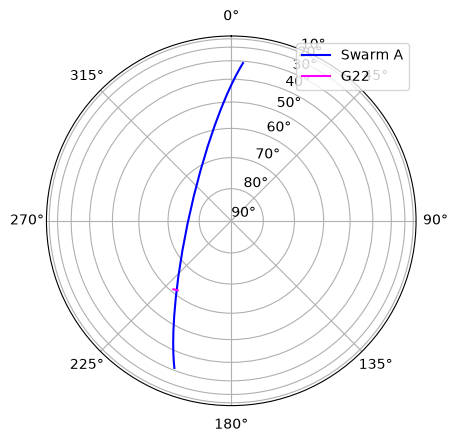

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='polar')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
el_ticks = np.arange(90., 0., -10.)
ax.set_ylim(0., 1.)
ax.set_yticks(np.cos(np.deg2rad(el_ticks)))
ax.set_yticklabels([rf'{el}$\degree$' for el in el_ticks.astype(int)])
ax.plot(np.deg2rad(azi), np.cos(np.deg2rad(eli)), color='blue', label=conj['Name'])
ax.plot(np.deg2rad(azg), np.cos(np.deg2rad(elg)), color='magenta', label=conj['PRN'])
ax.legend()

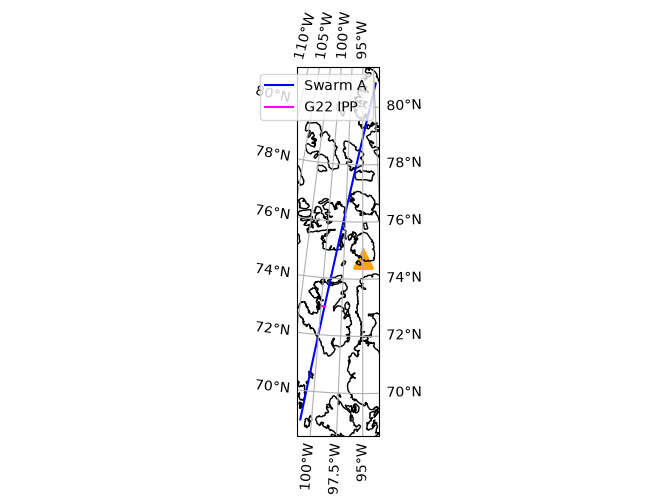

In [14]:

lati, loni, alti = pm.ecef2geodetic(conj['pass_info']['xi'], conj['pass_info']['yi'], conj['pass_info']['zi'])
# Can calculate IPPs either at a standard F region altitude (like 300 km) or at the average altitude of the in situ satellite during this pass
ipplatg, ipplong = calc_ipp(receiver_site, [azg, elg], height=np.mean(alti/1000.)) 

map_proj = ccrs.AzimuthalEquidistant(central_longitude=receiver_site[1], central_latitude=receiver_site[0])
fig = plt.figure()
ax = fig.add_subplot(111, projection=map_proj)

ax.plot(loni, lati, color='blue', label=conj['Name'], transform=ccrs.Geodetic())
ax.plot(ipplong, ipplatg, color='magenta', label=conj['PRN']+' IPP', transform=ccrs.Geodetic())

ax.scatter(receiver_site[1], receiver_site[0], s=200, color='orange', marker='^', transform=ccrs.Geodetic())
ax.coastlines()
ax.gridlines(draw_labels=True)
ax.legend()
#ax.set_extent([275.,295.,50.,65.])